# ДЗ 6. Предсказание вторичной структуры РНК с помощью MAMBA

Датасет: [ArchiveII](https://huggingface.co/datasets/multimolecule/archiveii) (~3900 последовательностей РНК с аннотацией вторичной структуры в формате dot-bracket).

Задача: по нуклеотидной последовательности предсказать для каждой позиции один из трёх классов — `unpaired` (неспаренная), `open` (открывающая скобка), `close` (закрывающая скобка).

## 1. Загрузка и подготовка данных

In [1]:
import numpy as np
import torch
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
from torch.autograd import Function
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau
from torch import Tensor
from einops import rearrange
import math
from torch import nn
from collections import defaultdict
from datasets import load_dataset
import os
import random
import time
import pandas as pd
import matplotlib.pyplot as plt
from typing import Callable

In [2]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

Словарь из 5 нуклеотидов (A, U, G, C, N) + PAD-токен. Разметка dot-bracket в три класса позиций.

In [3]:
NUC_VOCAB = {"A": 0, "U": 1, "G": 2, "C": 3, "T": 1, "N": 4, "<PAD>": 5}
LABEL_VOCAB = {"unpaired": 0, "open": 1, "close": 2}

PAD_TOKEN = NUC_VOCAB["<PAD>"]
PAD_LABEL = -100


def dot_bracket_to_pairs(db: str) -> list:
    stack, pairs = [], []
    for i, c in enumerate(db):
        if c == "(":
            stack.append(i)
        elif c == ")" and stack:
            pairs.append((stack.pop() + 1, i + 1))
    return pairs


def pairs_to_labels(pairs: list, length: int) -> torch.Tensor:
    labels = torch.zeros(length, dtype=torch.long)
    for i, j in pairs:
        if 1 <= i <= length and 1 <= j <= length:
            labels[i - 1] = 1
            labels[j - 1] = 2
    return labels


def preprocess(row):
    seq = row["sequence"].upper().replace("T", "U")
    db = row["secondary_structure"]
    L = len(seq)
    pairs = dot_bracket_to_pairs(db)
    return {
        "tokens": [NUC_VOCAB.get(c, NUC_VOCAB["N"]) for c in seq],
        "labels": pairs_to_labels(pairs, L).tolist(),
        "length": L,
    }


hf = load_dataset("multimolecule/archiveii", split="test")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md:   0%|          | 0.00/4.01k [00:00<?, ?B/s]

test.parquet:   0%|          | 0.00/283k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/3975 [00:00<?, ? examples/s]

Фильтрация последовательностей по длине (10–512) и токенизация.

In [4]:
hf_data = hf.filter(lambda x: 10 <= len(x["sequence"]) <= 512, num_proc=8).map(
    preprocess, num_proc=8
)

Filter (num_proc=8):   0%|          | 0/3975 [00:00<?, ? examples/s]

Map (num_proc=8):   0%|          | 0/3865 [00:00<?, ? examples/s]

In [5]:
hf_data.set_format("torch", columns=["tokens", "labels", "length"])
hf_data = hf_data.class_encode_column("family")

Casting to class labels:   0%|          | 0/3865 [00:00<?, ? examples/s]

Стратифицированное разбиение по семействам РНК: ~70% train, ~15% val, ~15% test.

In [6]:
split1 = hf_data.train_test_split(test_size=0.15, seed=42, stratify_by_column="family")
test_ds = split1["test"]
split2 = split1["train"].train_test_split(
    test_size=0.176, seed=42, stratify_by_column="family"
)
train_ds, val_ds = split2["train"], split2["test"]

## 2. Модель

In [7]:
import torch.nn.functional as F


class PScan(Function):
    """Associative parallel scan: h_t = A_t · h_{t-1} + X_t.

    Inputs/outputs are (B, L, D, S). Length L must be a power of 2 — pad
    upstream when necessary.
    """

    @staticmethod
    def forward(ctx, A_inp, X_inp):
        A, X = A_inp.clone(), X_inp.clone()
        A, X = rearrange(A, "b l d s -> b d l s"), rearrange(X, "b l d s -> b d l s")
        PScan._forward(A, X)
        ctx.save_for_backward(A.clone(), X)
        return rearrange(X, "b d l s -> b l d s")

    @staticmethod
    def backward(ctx, grad_inp: Tensor) -> tuple[Tensor, Tensor]:
        A, X = ctx.saved_tensors
        A = torch.cat((A[:, :, :1], A[:, :, 1:].flip(2)), dim=2)
        grad_out = rearrange(grad_inp, "b l d s -> b d l s")
        grad_out = grad_out.flip(2)
        PScan._forward(A, grad_out)
        grad_out = grad_out.flip(2)
        Q = torch.zeros_like(X)
        Q[:, :, 1:].add_(X[:, :, :-1] * grad_out[:, :, 1:])
        return rearrange(Q, "b d l s -> b l d s"), rearrange(
            grad_out, "b d l s -> b l d s"
        )

    @staticmethod
    def _forward(A: Tensor, X: Tensor) -> None:
        b, d, l, _ = A.shape
        num_steps = int(math.log2(l))
        Av, Xv = A, X
        for _ in range(num_steps):
            T = Xv.size(2)
            Av, Xv = (
                Av[:, :, :T].reshape(b, d, T // 2, 2, -1),
                Xv[:, :, :T].reshape(b, d, T // 2, 2, -1),
            )
            Xv[:, :, :, 1].add_(Av[:, :, :, 1].mul(Xv[:, :, :, 0]))
            Av[:, :, :, 1].mul_(Av[:, :, :, 0])
            Av, Xv = Av[:, :, :, 1], Xv[:, :, :, 1]
        for k in range(num_steps - 1, -1, -1):
            Av, Xv = A[:, :, 2**k - 1 : l : 2**k], X[:, :, 2**k - 1 : l : 2**k]
            T = 2 * (Xv.size(2) // 2)
            if T < Xv.size(2):
                Xv[:, :, -1].add_(Av[:, :, -1].mul(Xv[:, :, -2]))
                Av[:, :, -1].mul_(Av[:, :, -2])
            Av, Xv = (
                Av[:, :, :T].reshape(b, d, T // 2, 2, -1),
                Xv[:, :, :T].reshape(b, d, T // 2, 2, -1),
            )
            Xv[:, :, 1:, 0].add_(Av[:, :, 1:, 0].mul(Xv[:, :, :-1, 1]))
            Av[:, :, 1:, 0].mul_(Av[:, :, :-1, 1])


pscan: Callable[[Tensor, Tensor], Tensor] = PScan.apply


def _next_pow2(n: int) -> int:
    return 1 << (n - 1).bit_length()


class RMSNorm(nn.Module):
    def __init__(self, d_model: int, eps: float = 1e-8) -> None:
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(d_model))

    def forward(self, x: Tensor) -> Tensor:
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps) * self.weight


class MambaBlock(nn.Module):
    """Selective SSM block (Mamba-1) built on top of the project's PScan.

    Stores per-token A_bar, B_bar, C, Delta, y on `self._cache` when
    `self.capture = True` for visualization.
    """

    def __init__(
        self, d_model: int, d_state: int = 16, d_conv: int = 4, expand: int = 2
    ):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        self.d_conv = d_conv
        self.d_inner = expand * d_model
        self.dt_rank = math.ceil(d_model / 16)

        self.norm = RMSNorm(d_model)
        self.in_proj = nn.Linear(d_model, 2 * self.d_inner, bias=False)
        self.conv1d = nn.Conv1d(
            self.d_inner,
            self.d_inner,
            kernel_size=d_conv,
            groups=self.d_inner,
            padding=d_conv - 1,
            bias=True,
        )
        self.x_proj = nn.Linear(self.d_inner, self.dt_rank + 2 * d_state, bias=False)
        self.dt_proj = nn.Linear(self.dt_rank, self.d_inner, bias=True)

        # dt bias init: softplus(bias) ~ U(dt_min, dt_max)
        dt_min, dt_max = 1e-3, 1e-1
        dt = torch.exp(
            torch.rand(self.d_inner) * (math.log(dt_max) - math.log(dt_min))
            + math.log(dt_min)
        )
        inv_softplus = dt + torch.log(-torch.expm1(-dt))
        with torch.no_grad():
            self.dt_proj.bias.copy_(inv_softplus)

        A = torch.arange(1, d_state + 1, dtype=torch.float32).repeat(self.d_inner, 1)
        self.A_log = nn.Parameter(torch.log(A))
        self.D = nn.Parameter(torch.ones(self.d_inner))
        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)

        self.capture: bool = False
        self._cache: dict[str, Tensor] = {}

    def _ssm(self, x_in: Tensor) -> Tensor:
        # x_in: (B, L, d_inner)
        B_size, L, _ = x_in.shape
        A = -torch.exp(self.A_log)
        dbc = self.x_proj(x_in)
        dt_raw, B_proj, C_proj = torch.split(
            dbc, [self.dt_rank, self.d_state, self.d_state], dim=-1
        )
        delta = F.softplus(self.dt_proj(dt_raw))
        A_bar = torch.exp(delta.unsqueeze(-1) * A)
        B_bar = delta.unsqueeze(-1) * B_proj.unsqueeze(-2)
        BX = B_bar * x_in.unsqueeze(-1)

        Lp = _next_pow2(L)
        if Lp != L:
            pad = Lp - L
            A_pad = torch.ones(
                B_size,
                pad,
                self.d_inner,
                self.d_state,
                dtype=A_bar.dtype,
                device=A_bar.device,
            )
            X_pad = torch.zeros(
                B_size,
                pad,
                self.d_inner,
                self.d_state,
                dtype=BX.dtype,
                device=BX.device,
            )
            A_run = torch.cat([A_bar, A_pad], dim=1)
            X_run = torch.cat([BX, X_pad], dim=1)
        else:
            A_run, X_run = A_bar, BX

        h = pscan(A_run.contiguous(), X_run.contiguous())[:, :L]
        y = (h * C_proj.unsqueeze(-2)).sum(-1) + self.D * x_in

        if self.capture:
            self._cache = {
                "delta": delta.detach().cpu(),
                "A_bar": A_bar.detach().cpu(),
                "B_bar": B_bar.detach().cpu(),
                "C": C_proj.detach().cpu(),
                "h": h.detach().cpu(),
                "y_pre_gate": y.detach().cpu(),
            }
        return y

    def forward(self, x: Tensor) -> Tensor:
        residual = x
        x = self.norm(x)
        xz = self.in_proj(x)
        x_in, z = xz.chunk(2, dim=-1)

        L = x_in.size(1)
        x_in = rearrange(x_in, "b l d -> b d l")
        x_in = self.conv1d(x_in)[:, :, :L]
        x_in = rearrange(x_in, "b d l -> b l d")
        x_in = F.silu(x_in)

        y = self._ssm(x_in)
        y = y * F.silu(z)
        return residual + self.out_proj(y)


class SinusoidalPE(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(
            torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, : x.size(1)]


class BiMambaClassifier(nn.Module):
    def __init__(
        self,
        n_layers: int,
        d_model: int,
        n_classes: int,
        vocab_size: int,
        max_len: int = 512,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_TOKEN)
        self.pos_embedding = SinusoidalPE(d_model, max_len=max_len)
        self.fwd_layers = nn.ModuleList([MambaBlock(d_model) for _ in range(n_layers)])
        self.bwd_layers = nn.ModuleList([MambaBlock(d_model) for _ in range(n_layers)])
        self.norm = RMSNorm(2 * d_model)
        self.classifier = nn.Sequential(
            nn.Dropout(0.1),
            nn.Linear(2 * d_model, d_model),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(d_model, n_classes),
        )

    def forward(
        self, tokens: Tensor, src_key_padding_mask: Tensor | None = None
    ) -> Tensor:
        x = self.embedding(tokens)
        x = self.pos_embedding(x)
        if src_key_padding_mask is not None:
            x = x.masked_fill(src_key_padding_mask.unsqueeze(-1), 0.0)

        fwd = x
        bwd = x.flip(1)
        for f, b in zip(self.fwd_layers, self.bwd_layers):
            fwd = f(fwd)
            bwd = b(bwd)
        bwd = bwd.flip(1)

        merged = self.norm(torch.cat([fwd, bwd], dim=-1))
        logits = self.classifier(merged)
        return logits.transpose(1, 2)


In [8]:
BATCH_SIZE = 32
NUM_EPOCHS = 60
LR = 1e-3
WEIGHT_DECAY = 1e-2

EMBED_DIM = 128
NUM_LAYERS = 4
NUM_CLASSES = 3

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

Using device: cuda


In [9]:
MAX_LEN = 512


def collate_fn(batch):
    B = len(batch)
    lengths = torch.tensor([b["length"] for b in batch])
    L_max = int(lengths.max())  # pad to longest in batch, not MAX_LEN
    tokens = torch.full((B, L_max), PAD_TOKEN, dtype=torch.long)
    labels = torch.full((B, L_max), PAD_LABEL, dtype=torch.long)
    for i, b in enumerate(batch):
        L = b["length"]
        tokens[i, :L] = b["tokens"]
        labels[i, :L] = b["labels"]
    mask = torch.arange(L_max).unsqueeze(0) >= lengths.unsqueeze(1)
    return {
        "tokens": tokens,
        "labels": labels,
        "lengths": lengths,
        "src_key_padding_mask": mask,
    }

In [10]:
from torch.utils.data import Sampler


class LengthBucketedBatchSampler(Sampler):
    """Yields batches with *similar* (not sorted) sequence lengths.

    Shuffle indices → cut into mega-buckets of `bucket_mult * batch_size` samples
    → sort each bucket by a noisy length key `len * (1 + U(-noise, noise))` so
    neighbouring samples have similar but not strictly identical length ordering
    → split each bucket into batches → shuffle batch order globally.

    The noise mitigates a known issue with strict length-bucketing: in datasets
    where length correlates with class (e.g. RNA family → length), strict sort
    makes each batch family-pure, biasing per-batch gradients. Noise breaks the
    correlation while keeping per-batch padding waste small.
    """

    def __init__(
        self,
        lengths,
        batch_size: int,
        shuffle: bool = True,
        bucket_mult: int = 8,
        noise: float = 0.1,
        drop_last: bool = False,
    ):
        self.lengths = list(lengths)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.bucket_mult = bucket_mult
        self.noise = noise
        self.drop_last = drop_last

    def __iter__(self):
        n = len(self.lengths)
        idx = list(range(n))
        if self.shuffle:
            random.shuffle(idx)
        bucket_size = self.batch_size * self.bucket_mult
        batches = []
        for s in range(0, n, bucket_size):
            bucket = idx[s : s + bucket_size]
            if self.shuffle and self.noise > 0:
                bucket.sort(
                    key=lambda i: (
                        self.lengths[i] * (1 + random.uniform(-self.noise, self.noise))
                    )
                )
            else:
                bucket.sort(key=lambda i: self.lengths[i])
            for b in range(0, len(bucket), self.batch_size):
                batch = bucket[b : b + self.batch_size]
                if self.drop_last and len(batch) < self.batch_size:
                    continue
                batches.append(batch)
        if self.shuffle:
            random.shuffle(batches)
        yield from batches

    def __len__(self):
        n = len(self.lengths)
        if self.drop_last:
            return n // self.batch_size
        return (n + self.batch_size - 1) // self.batch_size


def get_lengths(ds):
    col = ds["length"]
    return col.tolist() if hasattr(col, "tolist") else list(col)

In [11]:
train_sampler = LengthBucketedBatchSampler(
    get_lengths(train_ds), batch_size=BATCH_SIZE, shuffle=True
)
val_sampler = LengthBucketedBatchSampler(
    get_lengths(val_ds), batch_size=BATCH_SIZE, shuffle=False
)
test_sampler = LengthBucketedBatchSampler(
    get_lengths(test_ds), batch_size=BATCH_SIZE, shuffle=False
)

train_loader = DataLoader(
    train_ds, batch_sampler=train_sampler, collate_fn=collate_fn, num_workers=0
)
val_loader = DataLoader(
    val_ds, batch_sampler=val_sampler, collate_fn=collate_fn, num_workers=0
)
test_loader = DataLoader(
    test_ds, batch_sampler=test_sampler, collate_fn=collate_fn, num_workers=0
)

In [12]:
def make_loss_fn(dataset):
    counts = torch.zeros(3)
    for s in dataset:
        labels = s["labels"]
        for c in range(3):
            counts[c] += (labels == c).sum()

    weights = counts.sum() / (3 * counts)
    weights /= weights.sum()
    print(
        f"Class weights — unpaired: {weights[0]:.3f} | open: {weights[1]:.3f} | close: {weights[2]:.3f}"
    )
    return torch.nn.CrossEntropyLoss(weight=weights, ignore_index=PAD_LABEL)

## 3. Обучение

In [13]:
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR

WARMUP_EPOCHS = 3

model = BiMambaClassifier(
    n_layers=NUM_LAYERS,
    d_model=EMBED_DIM,
    n_classes=NUM_CLASSES,
    vocab_size=len(NUC_VOCAB),
    max_len=MAX_LEN,
).to(device)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = SequentialLR(
    optimizer,
    schedulers=[
        LinearLR(
            optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EPOCHS
        ),
        CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS, eta_min=1e-6),
    ],
    milestones=[WARMUP_EPOCHS],
)
criterion = make_loss_fn(train_ds).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Параметров: {n_params:,}")

Class weights — unpaired: 0.242 | open: 0.379 | close: 0.379
Параметров: 967,299


Тут я попросил claude оптимизировать подсчет метрик

In [14]:
@torch.no_grad()
def update_confusion(counts_3, preds, labels):
    # counts_3 lives on CPU as long tensor; preds/labels on device
    valid = labels != PAD_LABEL  # (B, L) bool — masks pad
    t = labels[valid]  # (N,)
    p = preds[valid]  # (N,)
    bins = torch.bincount(t * 3 + p, minlength=9).reshape(3, 3)
    counts_3 += bins.cpu()  # ONE sync per batch


def metrics_from_cm(cm):  # cm: 3x3 long
    cm = cm.float()
    # Binary "any pair" metrics: class 0 = unpaired, {1,2} = paired
    tp = cm[1:, 1:].sum()
    fp = cm[0, 1:].sum()
    fn = cm[1:, 0].sum()
    tn = cm[0, 0]
    sens = tp / (tp + fn + 1e-8)
    ppv = tp / (tp + fp + 1e-8)
    f1 = 2 * sens * ppv / (sens + ppv + 1e-8)
    num = tp * tn - fp * fn
    den = ((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)).sqrt()
    mcc = num / (den + 1e-8)
    # Macro F1
    f1s = []
    for c in range(3):
        tpc = cm[c, c]
        prec = tpc / (cm[:, c].sum() + 1e-8)
        rec = tpc / (cm[c, :].sum() + 1e-8)
        f1s.append((2 * prec * rec / (prec + rec + 1e-8)).item())
    return {
        "f1": f1.item(),
        "sensitivity": sens.item(),
        "ppv": ppv.item(),
        "mcc": mcc.item(),
        "f1_macro": float(np.mean(f1s)),
    }


def run_epoch(model, loader, criterion, device, optimizer=None):
    train = optimizer is not None
    model.train() if train else model.eval()

    counts_3 = torch.zeros(3, 3, dtype=torch.long)
    total_loss, n_samples = 0.0, 0

    grad_ctx = torch.enable_grad() if train else torch.no_grad()
    with grad_ctx:
        for batch in loader:
            tokens = batch["tokens"].to(device, non_blocking=True)
            labels = batch["labels"].to(device, non_blocking=True)
            mask = batch["src_key_padding_mask"].to(device, non_blocking=True)
            B = tokens.size(0)

            logits = model(tokens, src_key_padding_mask=mask)
            loss = criterion(logits, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * B
            n_samples += B
            update_confusion(counts_3, logits.detach().argmax(1), labels)

    metrics = metrics_from_cm(counts_3)
    metrics["loss"] = total_loss / n_samples
    return metrics

In [15]:
best_val_metric = float("inf")  # tracking val loss now — lower is better
best_model_state = None
patience, patience_counter = 6, 0  # tighter than before: val loss plateaus fast
train_history: list[dict[str, float]] = []
val_history: list[dict[str, float]] = []


for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    train_metrics = run_epoch(model, train_loader, criterion, device, optimizer)
    val_metrics = run_epoch(model, val_loader, criterion, device)
    scheduler.step()  # cosine — no metric needed
    elapsed = time.time() - t0

    train_metrics["epoch"] = val_metrics["epoch"] = epoch
    train_history.append(train_metrics)
    val_history.append(val_metrics)

    lr_now = optimizer.param_groups[0]["lr"]
    print(
        f"Epoch {epoch:2d}/{NUM_EPOCHS} | lr {lr_now:.2e} | "
        f"Train Loss: {train_metrics['loss']:.4f}  F1: {train_metrics['f1']:.4f} F1M: {train_metrics['f1_macro']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}  F1: {val_metrics['f1']:.4f}  MCC {val_metrics['mcc']:.4f} F1M: {val_metrics['f1_macro']:.4f} | "
        f"{elapsed:.1f}s"
    )

    if val_metrics["loss"] < best_val_metric:
        best_val_metric = val_metrics["loss"]
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break
assert best_model_state is not None, "No model state was saved during training!"
model.load_state_dict(best_model_state)

Epoch  1/60 | lr 4.00e-04 | Train Loss: 1.0187  F1: 0.7034 F1M: 0.4618 | Val Loss: 0.9171  F1: 0.7286  MCC 0.2872 F1M: 0.5052 | 52.7s
Epoch  2/60 | lr 7.00e-04 | Train Loss: 0.8434  F1: 0.7410 F1M: 0.5483 | Val Loss: 0.7507  F1: 0.7551  MCC 0.3868 F1M: 0.5931 | 50.8s
Epoch  3/60 | lr 1.00e-03 | Train Loss: 0.7136  F1: 0.7646 F1M: 0.6082 | Val Loss: 0.6352  F1: 0.7795  MCC 0.4521 F1M: 0.6290 | 52.0s
Epoch  4/60 | lr 9.99e-04 | Train Loss: 0.5817  F1: 0.7917 F1M: 0.6609 | Val Loss: 0.5009  F1: 0.8078  MCC 0.5300 F1M: 0.6957 | 53.1s
Epoch  5/60 | lr 9.97e-04 | Train Loss: 0.4759  F1: 0.8156 F1M: 0.7070 | Val Loss: 0.4623  F1: 0.8221  MCC 0.5606 F1M: 0.7118 | 52.1s
Epoch  6/60 | lr 9.93e-04 | Train Loss: 0.4232  F1: 0.8299 F1M: 0.7339 | Val Loss: 0.4122  F1: 0.8290  MCC 0.5943 F1M: 0.7454 | 51.9s
Epoch  7/60 | lr 9.88e-04 | Train Loss: 0.3685  F1: 0.8427 F1M: 0.7615 | Val Loss: 0.3760  F1: 0.8415  MCC 0.6222 F1M: 0.7648 | 51.9s
Epoch  8/60 | lr 9.81e-04 | Train Loss: 0.3491  F1: 0.8521 F1M

<All keys matched successfully>

### График обучения

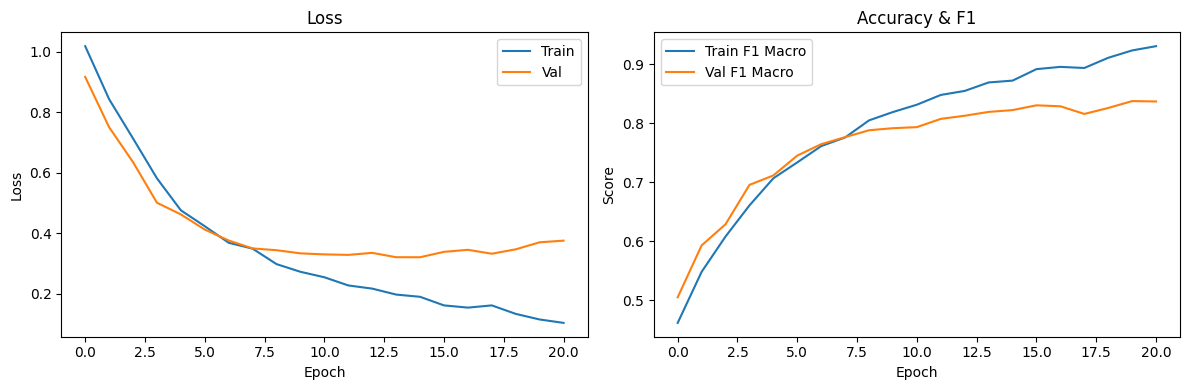

In [16]:
train_hist_df = pd.DataFrame(train_history)
val_hist_df = pd.DataFrame(val_history)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_hist_df.loss, label="Train")
ax1.plot(val_hist_df.loss, label="Val")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.set_title("Loss")

ax2.plot(train_hist_df.f1_macro, label="Train F1 Macro")
ax2.plot(val_hist_df.f1_macro, label="Val F1 Macro")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Score")
ax2.legend()
ax2.set_title("Accuracy & F1")

plt.tight_layout()
plt.show()

## 4. Оценка на тесте

In [17]:
test_loader = DataLoader(
    test_ds, batch_sampler=test_sampler, collate_fn=collate_fn, num_workers=0
)
run_epoch(model, test_loader, criterion, device)

{'f1': 0.8812406659126282,
 'sensitivity': 0.9279593825340271,
 'ppv': 0.8390006422996521,
 'mcc': 0.7155970931053162,
 'f1_macro': 0.8322869340578715,
 'loss': 0.29897432471143787}

## 5. Визуализация SSM

У Mamba нет матрицы внимания, поэтому вместо неё мы смотрим на:
- $\Delta$ (selectivity) - насколько сильно каждая позиция обновляет скрытое состояние,
- $K[i, j] = C_i · (\Pi_{k=j+1..i} \overline{A}_k) · \overline{B}_j$ — SSM-аналог attention map: вклад входа в позиции $j$ в выход в позиции $i$.


In [18]:
from contextlib import contextmanager


@contextmanager
def capture_ssm(model):
    """Enable per-token SSM capture on every MambaBlock.

    Yields a dict that is populated AFTER the `with` block exits:
    `{"fwd": [layer_cache, ...], "bwd": [layer_cache, ...]}`.
    Read from it outside the `with`, not inside — inside the body the dict is
    still empty because `MambaBlock._ssm` reassigns `self._cache` to a fresh
    dict on each forward, so a list grabbed at __enter__ time would just hold
    stale references to the initial empty dicts.
    """
    fwd_blocks = list(model.fwd_layers)
    bwd_blocks = list(model.bwd_layers)
    for m in fwd_blocks + bwd_blocks:
        m.capture = True
        m._cache = {}
    caches: dict = {"fwd": [], "bwd": []}
    try:
        yield caches
    finally:
        caches["fwd"] = [m._cache for m in fwd_blocks]
        caches["bwd"] = [m._cache for m in bwd_blocks]
        for m in fwd_blocks + bwd_blocks:
            m.capture = False


def ssm_kernel(cache, L: int, chunk: int = 32) -> np.ndarray:
    """Effective input→output kernel K[i, j] for one MambaBlock.

        K[i, j] = mean_d ( C_i · ( ∏_{k=j+1..i} Ā_k[d, :] ) · B̄_j[d, :] )   for j ≤ i
                = 0                                                          for j  > i

    Computed in the layer's own reading frame. For the backward stack, flip both
    axes via `K[::-1, ::-1]` to put it back in RNA coordinates (upper-triangular).
    Chunks over d_inner to keep peak memory low.
    """
    A_bar = cache["A_bar"][0, :L].float()
    B_bar = cache["B_bar"][0, :L].float()
    C = cache["C"][0, :L].float()
    d_inner = A_bar.size(1)

    log_A = torch.log(A_bar.clamp_min(1e-30))
    cum_logA = torch.cumsum(log_A, dim=0)

    K_sum = torch.zeros(L, L)
    for s in range(0, d_inner, chunk):
        e = min(s + chunk, d_inner)
        cum_i = cum_logA[:, s:e].unsqueeze(1)
        cum_j = cum_logA[:, s:e].unsqueeze(0)
        prod_ij = torch.exp(cum_i - cum_j)
        prod_ij = prod_ij * B_bar[:, s:e].unsqueeze(0)
        K_chunk = (prod_ij * C.unsqueeze(1).unsqueeze(-2)).sum(-1).sum(-1)
        K_sum += K_chunk
    K = K_sum / d_inner

    mask = torch.triu(torch.ones(L, L), diagonal=1).bool()
    K = K.masked_fill(mask, 0.0)
    return K.numpy()


Выбираем короткую последовательность (50–80 нт) с высокой долей спаренных позиций — на ней паттерны внимания будут наиболее читаемыми.

In [19]:
for i, sample in enumerate(test_ds):
    L = sample["length"].item()
    n_paired = (sample["labels"] != 0).sum().item()
    ratio = n_paired / L
    if 50 <= L <= 80 and ratio > 0.5:
        print(f"idx={i}  L={L}  paired={n_paired}  ratio={ratio:.2f}")

idx=0  L=75  paired=40  ratio=0.53
idx=2  L=72  paired=40  ratio=0.56
idx=12  L=78  paired=42  ratio=0.54
idx=39  L=75  paired=44  ratio=0.59
idx=46  L=76  paired=40  ratio=0.53
idx=62  L=71  paired=42  ratio=0.59
idx=64  L=74  paired=44  ratio=0.59
idx=68  L=76  paired=44  ratio=0.58
idx=71  L=75  paired=42  ratio=0.56
idx=80  L=67  paired=40  ratio=0.60
idx=104  L=76  paired=42  ratio=0.55
idx=116  L=76  paired=42  ratio=0.55
idx=118  L=76  paired=42  ratio=0.55
idx=120  L=76  paired=42  ratio=0.55
idx=124  L=76  paired=44  ratio=0.58
idx=138  L=78  paired=40  ratio=0.51
idx=151  L=76  paired=40  ratio=0.53
idx=168  L=77  paired=42  ratio=0.55
idx=178  L=73  paired=40  ratio=0.55
idx=182  L=76  paired=42  ratio=0.55
idx=201  L=75  paired=42  ratio=0.56
idx=205  L=78  paired=42  ratio=0.54
idx=209  L=75  paired=42  ratio=0.56
idx=225  L=77  paired=40  ratio=0.52
idx=231  L=76  paired=42  ratio=0.55
idx=235  L=76  paired=42  ratio=0.55
idx=236  L=77  paired=44  ratio=0.57
idx=246  L=75

Взял №27, так как модель предсказывает его на 100% правильно.

In [20]:
model.eval()
sample_idx = 270
sample = test_ds[sample_idx]
L = sample["length"].item()

tokens = sample["tokens"].unsqueeze(0).to(device)

with capture_ssm(model) as caches:
    with torch.no_grad():
        logits = model(tokens)

fwd_caches = caches["fwd"]
bwd_caches = caches["bwd"]

K_fwd = [ssm_kernel(c, L) for c in fwd_caches]
K_bwd = [ssm_kernel(c, L)[::-1, ::-1].copy() for c in bwd_caches]

print(f"Длина последовательности: {L}")
print(f"Слоёв: forward={len(K_fwd)}, backward={len(K_bwd)}")


Длина последовательности: 76
Слоёв: forward=4, backward=4


### 5.1 SSM-ядра по слоям

Для каждого Mamba-слоя строим эффективное ядро $K[i, j]$ в координатах входной РНК-последовательности. Forward-стек видит причинно прошлое (нижний треугольник), backward — будущее (верхний треугольник после `flip`).

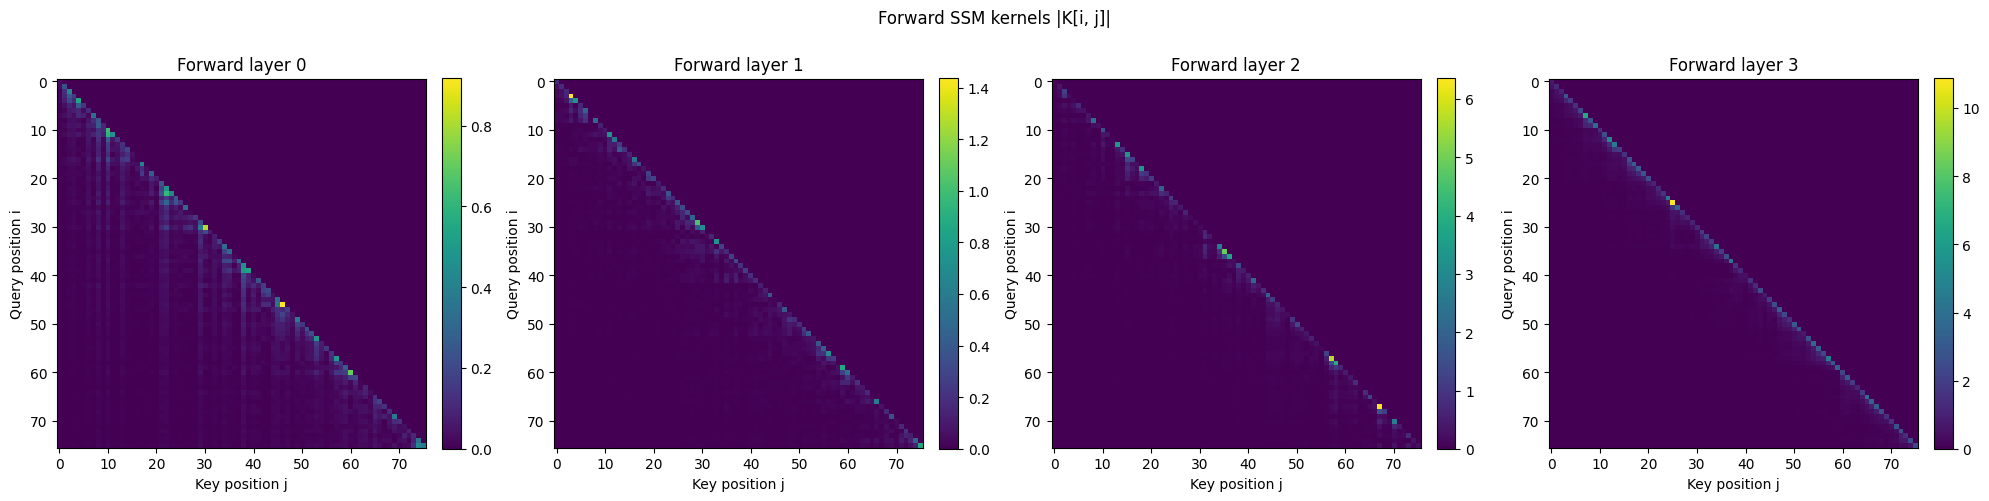

In [21]:
n_layers = len(K_fwd)
fig, axes = plt.subplots(1, n_layers, figsize=(5 * n_layers, 5))
if n_layers == 1:
    axes = [axes]
for i, K in enumerate(K_fwd):
    im = axes[i].imshow(np.abs(K), cmap="viridis", aspect="equal")
    axes[i].set_title(f"Forward layer {i}")
    axes[i].set_xlabel("Key position j")
    axes[i].set_ylabel("Query position i")
    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
plt.suptitle("Forward SSM kernels |K[i, j]|")
plt.tight_layout()
plt.show()

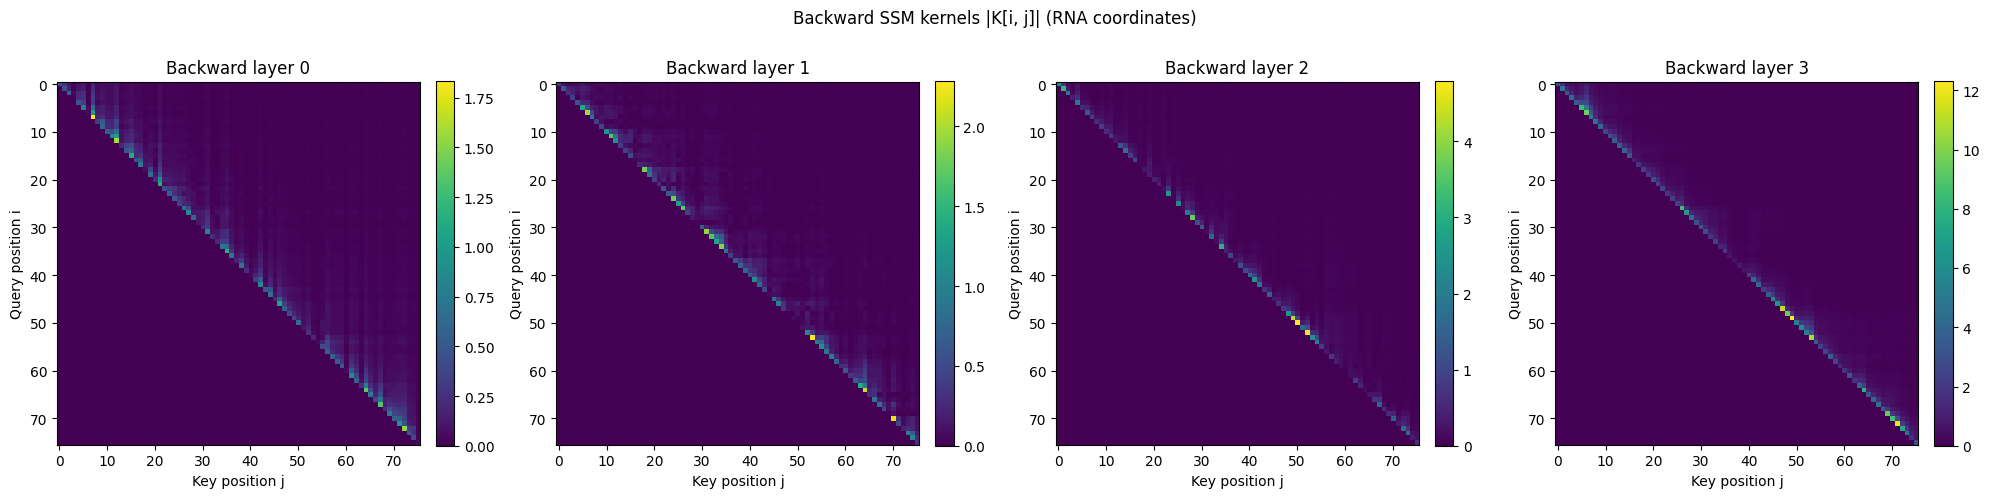

In [22]:
n_layers = len(K_bwd)
fig, axes = plt.subplots(1, n_layers, figsize=(5 * n_layers, 5))
if n_layers == 1:
    axes = [axes]
for i, K in enumerate(K_bwd):
    im = axes[i].imshow(np.abs(K), cmap="viridis", aspect="equal")
    axes[i].set_title(f"Backward layer {i}")
    axes[i].set_xlabel("Key position j")
    axes[i].set_ylabel("Query position i")
    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
plt.suptitle("Backward SSM kernels |K[i, j]| (RNA coordinates)")
plt.tight_layout()
plt.show()

### 5.2 Сравнение симметризованного ядра с контактной картой

Контактная карта — бинарная (L×L) матрица спариваний. Симметризуем эффективное ядро: `K_sym = |K_fwd_last| + |K_bwd_last|ᵀ` — оба слагаемых описывают вклад позиции `j` в позицию `i`, но в разных направлениях.

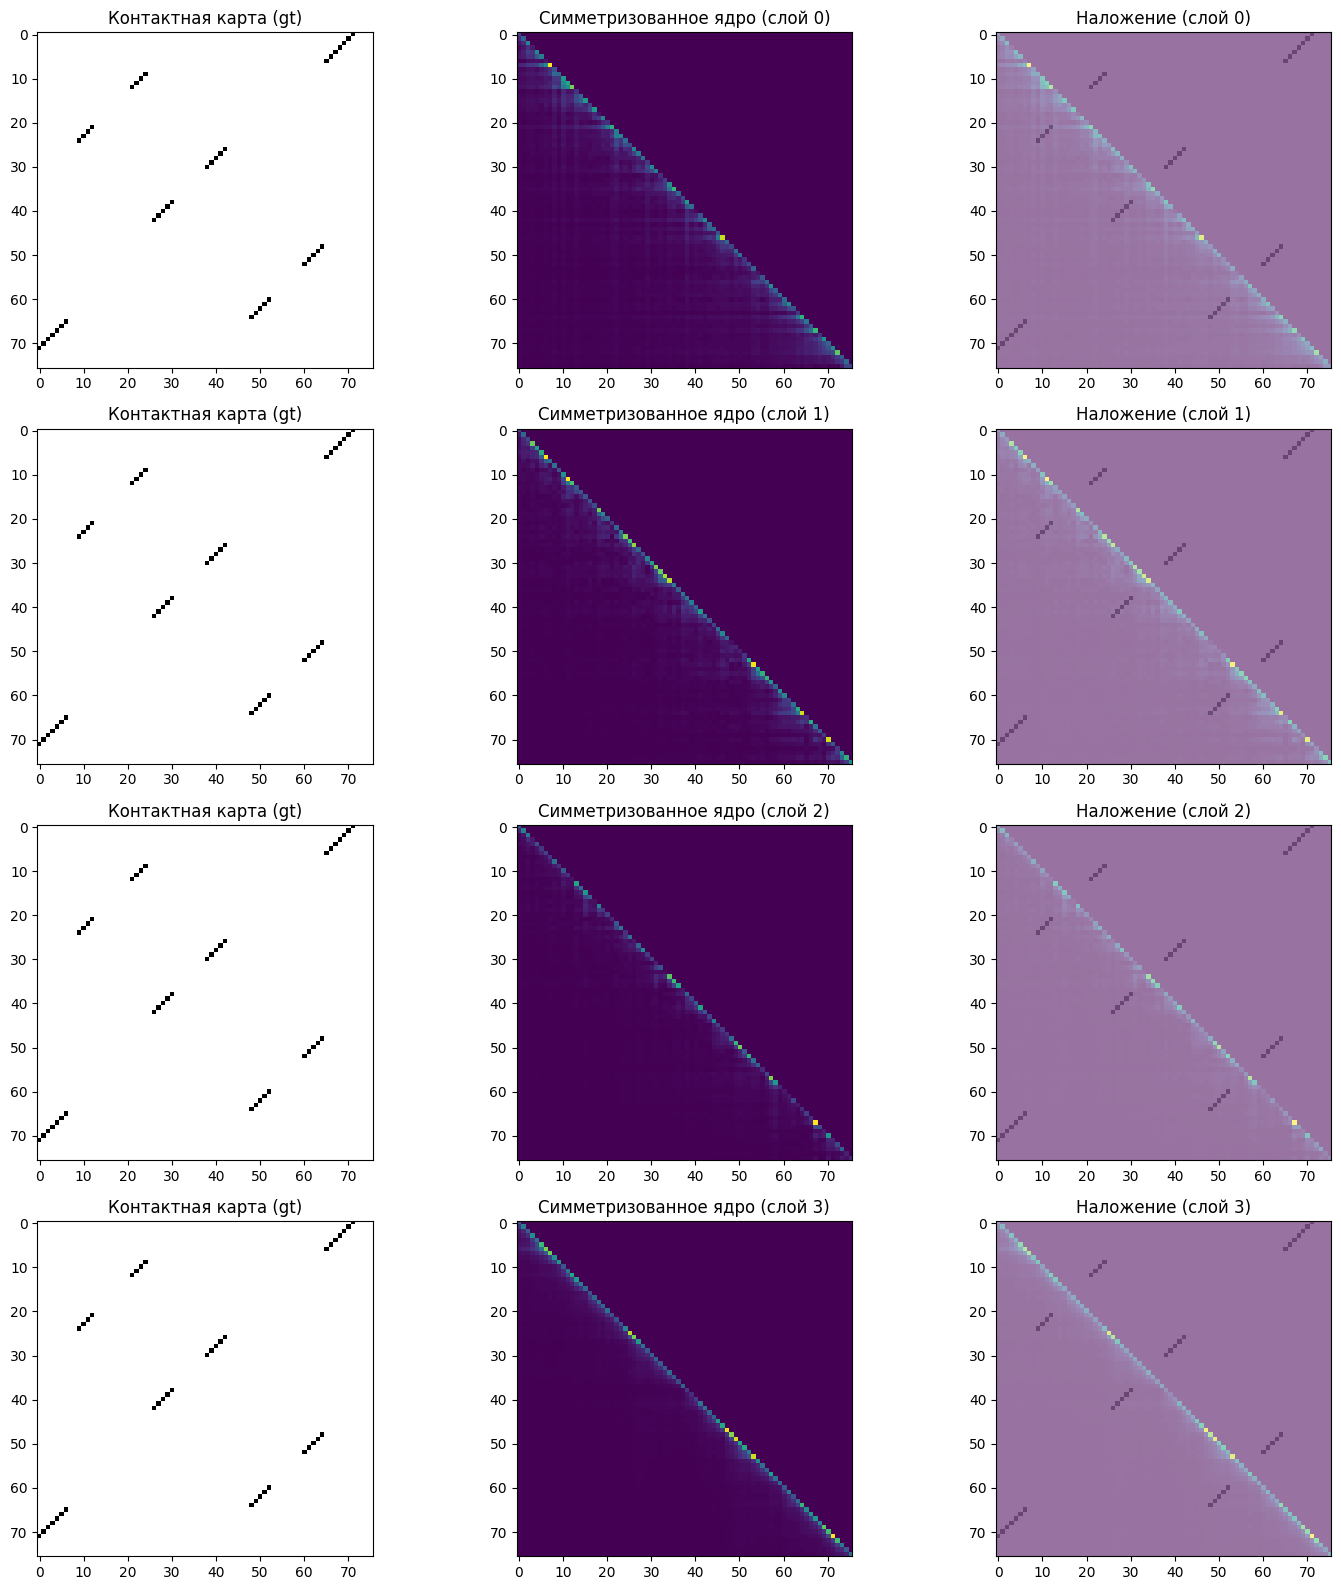

In [23]:
test_ds.reset_format()
secondary_structure = test_ds[sample_idx]["secondary_structure"]
test_ds.set_format("torch", columns=["tokens", "labels", "length"])

pairs = dot_bracket_to_pairs(secondary_structure)
contact = torch.zeros(L, L)
for i, j in pairs:
    if 1 <= i <= L and 1 <= j <= L:
        contact[i - 1, j - 1] = contact[j - 1, i - 1] = 1.0

n_layers = len(K_fwd)
fig, axes = plt.subplots(n_layers, 3, figsize=(15, 4 * n_layers))
if n_layers == 1:
    axes = axes[None, :]
for li in range(n_layers):
    K_sym = np.abs(K_fwd[li]) + np.abs(K_bwd[li]).T

    axes[li, 0].imshow(contact.numpy(), cmap="Greys")
    axes[li, 0].set_title(f"Контактная карта (gt)")

    axes[li, 1].imshow(K_sym, cmap="viridis")
    axes[li, 1].set_title(f"Симметризованное ядро (слой {li})")

    axes[li, 2].imshow(contact.numpy(), cmap="Greys", alpha=0.4)
    axes[li, 2].imshow(K_sym, cmap="viridis", alpha=0.55)
    axes[li, 2].set_title(f"Наложение (слой {li})")
plt.tight_layout()
plt.show()


### 5.3 Профиль селективности Δ и затухание ядра по расстоянию

Слева — $\overline{\Delta}(i) = mean_{\text{d\_inner}}(\Delta_l[i])$ для каждого слоя forward-стека. Пики Δ означают, что слой «обновляет» состояние именно в этих позициях (аналог спайков внимания).
Справа — среднее $|K_fwd[i, i-d]|$ по $i$ как функция от расстояния $d$ (видно, насколько далеко SSM помнит вход).

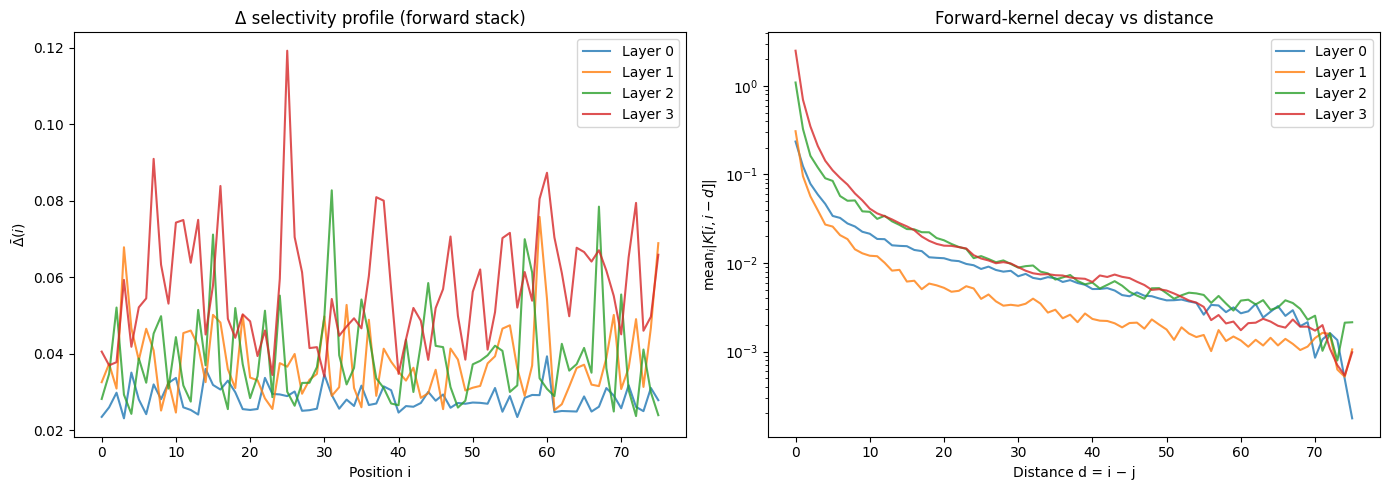

In [24]:
fig, (ax_delta, ax_decay) = plt.subplots(1, 2, figsize=(14, 5))

for li, c in enumerate(fwd_caches):
    delta = c["delta"][0, :L].mean(-1).numpy()  # (L,)
    ax_delta.plot(delta, label=f"Layer {li}", alpha=0.8)
ax_delta.set_xlabel("Position i")
ax_delta.set_ylabel(r"$\bar\Delta(i)$")
ax_delta.set_title("Δ selectivity profile (forward stack)")
ax_delta.legend()

for li, K in enumerate(K_fwd):
    K_abs = np.abs(K)
    max_d = L - 1
    decay = np.zeros(max_d + 1)
    counts = np.zeros(max_d + 1)
    for i in range(L):
        for j in range(i + 1):
            d = i - j
            decay[d] += K_abs[i, j]
            counts[d] += 1
    decay = decay / np.maximum(counts, 1)
    ax_decay.plot(decay, label=f"Layer {li}", alpha=0.8)
ax_decay.set_xlabel("Distance d = i − j")
ax_decay.set_ylabel(r"mean$_i |K[i, i-d]|$")
ax_decay.set_title("Forward-kernel decay vs distance")
ax_decay.set_yscale("log")
ax_decay.legend()

plt.tight_layout()
plt.show()

### 5.4 Предсказание vs ground truth

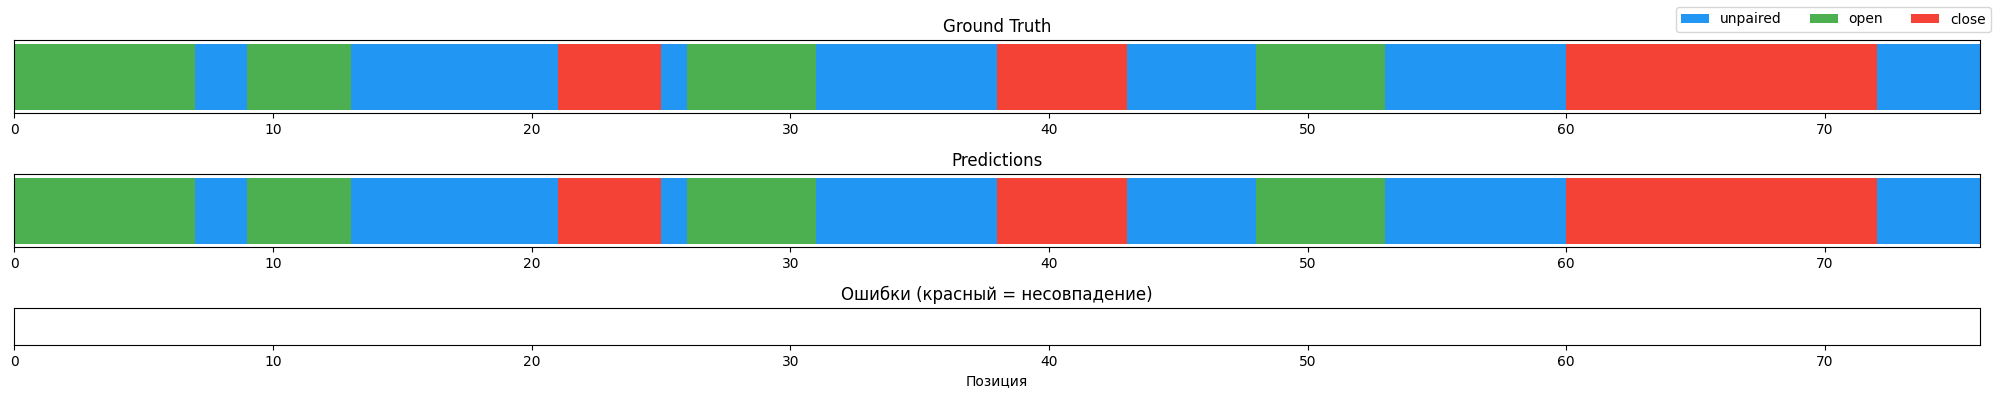

Per-position accuracy: 100.00% (76/76)


In [25]:
sample = test_ds[sample_idx]
tokens = sample["tokens"].unsqueeze(0).to(device)
L = sample["length"].item()

with torch.no_grad():
    logits = model(tokens)
preds = logits.argmax(1).squeeze().cpu()[:L].numpy()
labels = sample["labels"][:L].numpy()

label_names = {0: "unpaired", 1: "open", 2: "close"}
colors = {0: "#2196F3", 1: "#4CAF50", 2: "#F44336"}

fig, axes = plt.subplots(
    3, 1, figsize=(20, 4), gridspec_kw={"height_ratios": [1, 1, 0.5]}
)

for i in range(L):
    axes[0].barh(0, 1, left=i, color=colors[labels[i]], edgecolor="none")
axes[0].set_xlim(0, L)
axes[0].set_yticks([])
axes[0].set_title("Ground Truth")

for i in range(L):
    axes[1].barh(0, 1, left=i, color=colors[preds[i]], edgecolor="none")
axes[1].set_xlim(0, L)
axes[1].set_yticks([])
axes[1].set_title("Predictions")

for i in range(L):
    axes[2].barh(
        0,
        1,
        left=i,
        color="red" if preds[i] != labels[i] else "white",
        edgecolor="none",
    )
axes[2].set_xlim(0, L)
axes[2].set_yticks([])
axes[2].set_title("Ошибки (красный = несовпадение)")
axes[2].set_xlabel("Позиция")

from matplotlib.patches import Patch

legend_elements = [Patch(facecolor=colors[k], label=v) for k, v in label_names.items()]
fig.legend(handles=legend_elements, loc="upper right", ncol=3)
plt.tight_layout()
plt.show()

acc = (preds == labels).mean()
print(f"Per-position accuracy: {acc:.2%} ({(preds == labels).sum()}/{L})")


## 6. Выводы

На графиках видно, что внимание в основном сфокусировано вокруг области токена. То есть модель в основном использовала информацию из непосредственного окружения нуклуотида.
Графики сделаны с помощью llm.